# CELL 1: IMPORT ALL LIBRARIES

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# Style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


# CELL 2: LOAD DATASET

In [2]:
df = pd.read_csv('../data/titanic.csv')

# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# New columns
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['AgeGroup'] = pd.cut(df['Age'], 
                         bins=[0,12,18,35,60,100],
                         labels=['Child','Teen','Adult','Middle Age','Senior'])
df['FareGroup'] = pd.cut(df['Fare'],
                          bins=[0,10,30,100,600],
                          labels=['Low','Medium','High','Very High'])

print("✅ Dataset Loaded & Prepared!")
print(f"📊 Rows: {df.shape[0]} | Columns: {df.shape[1]}")

✅ Dataset Loaded & Prepared!
📊 Rows: 891 | Columns: 15


# CELL 3: ADVANCED CORRELATION HEATMAP

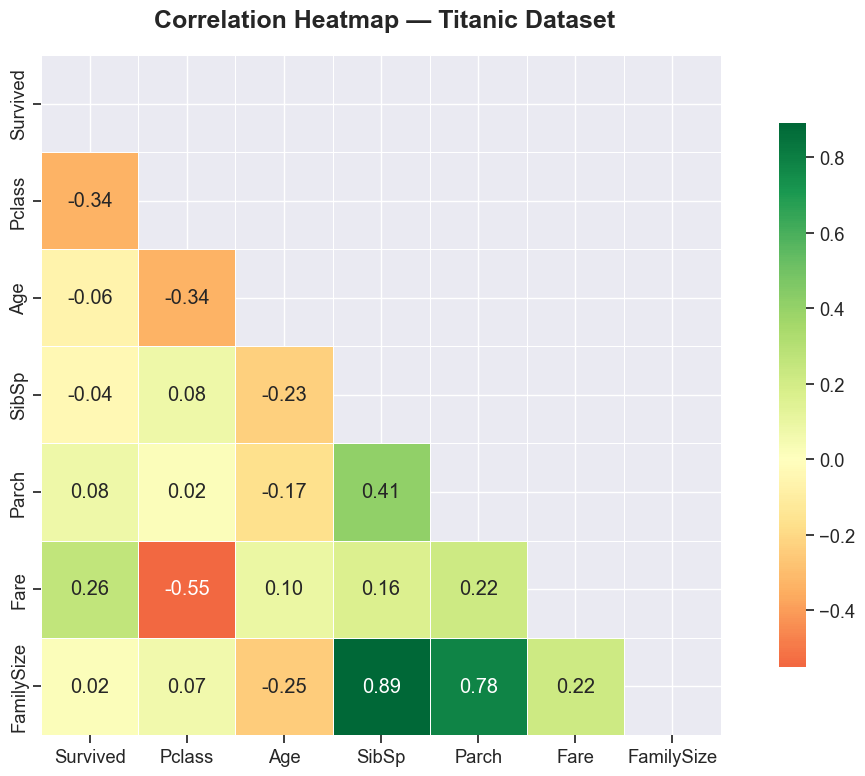

✅ Correlation Heatmap saved!


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# Select numeric columns
numeric_df = df[['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']]

# Correlation matrix
corr_matrix = numeric_df.corr()

# Beautiful mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            ax=ax)

ax.set_title(' Correlation Heatmap — Titanic Dataset',
             fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Correlation Heatmap saved!")

# Correlation Heatmap — Explanation

**What does this chart show?**
How much relationship exists between two variables

*How to read it?*
🟢 Green Color  → Positive relation 
                  (both increase together)
🔴 Red Color    → Negative relation 
                  (one increases, other decreases)
⚪ White Color  → No relation at 

Key Insights:
✅ Pclass & Survived → Negative (-0.34)
   Meaning: Higher class number (3rd) = Less survival

✅ Fare & Survived → Positive (+0.26)
   Meaning: Higher fare paid = More likely to survive

✅ Age & Survived → Slightly negative
   Meaning: Older passengers survived less


 **Cell 4: Interactive Survival Chart**

In [ ]:

# INTERACTIVE SURVIVAL BY GENDER & CLASS

survival_data = df.groupby(['Pclass','Sex'])['Survived'].mean().reset_index()
survival_data['Survival Rate (%)'] = (survival_data['Survived'] * 100).round(1)
survival_data['Class'] = survival_data['Pclass'].map({1:'1st Class',2:'2nd Class',3:'3rd Class'})

fig = px.bar(survival_data,
             x='Class',
             y='Survival Rate (%)',
             color='Sex',
             barmode='group',
             title=' Survival Rate by Passenger Class & Gender',
             color_discrete_map={'male':'#3498DB','female':'#E91E63'},
             text='Survival Rate (%)',
             height=500)

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(
    title_font_size=20,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=14),
    legend_title='Gender',
    xaxis_title='Passenger Class',
    yaxis_title='Survival Rate (%)',
    yaxis=dict(range=[0,100])
)

fig.write_html('../dashboard/survival_by_class_gender.html')
fig.show()
print("✅ Interactive Chart saved!")

✅ Interactive Chart saved!


# Interactive Bar Chart — Explanation

Key Insights:

✅ 1st Class Female → Highest survival (~97%)
✅ 3rd Class Male   → Lowest survival (~15%)
✅ In every class Female > Male survival rate

**Cell 5: Age Distribution Advanced**

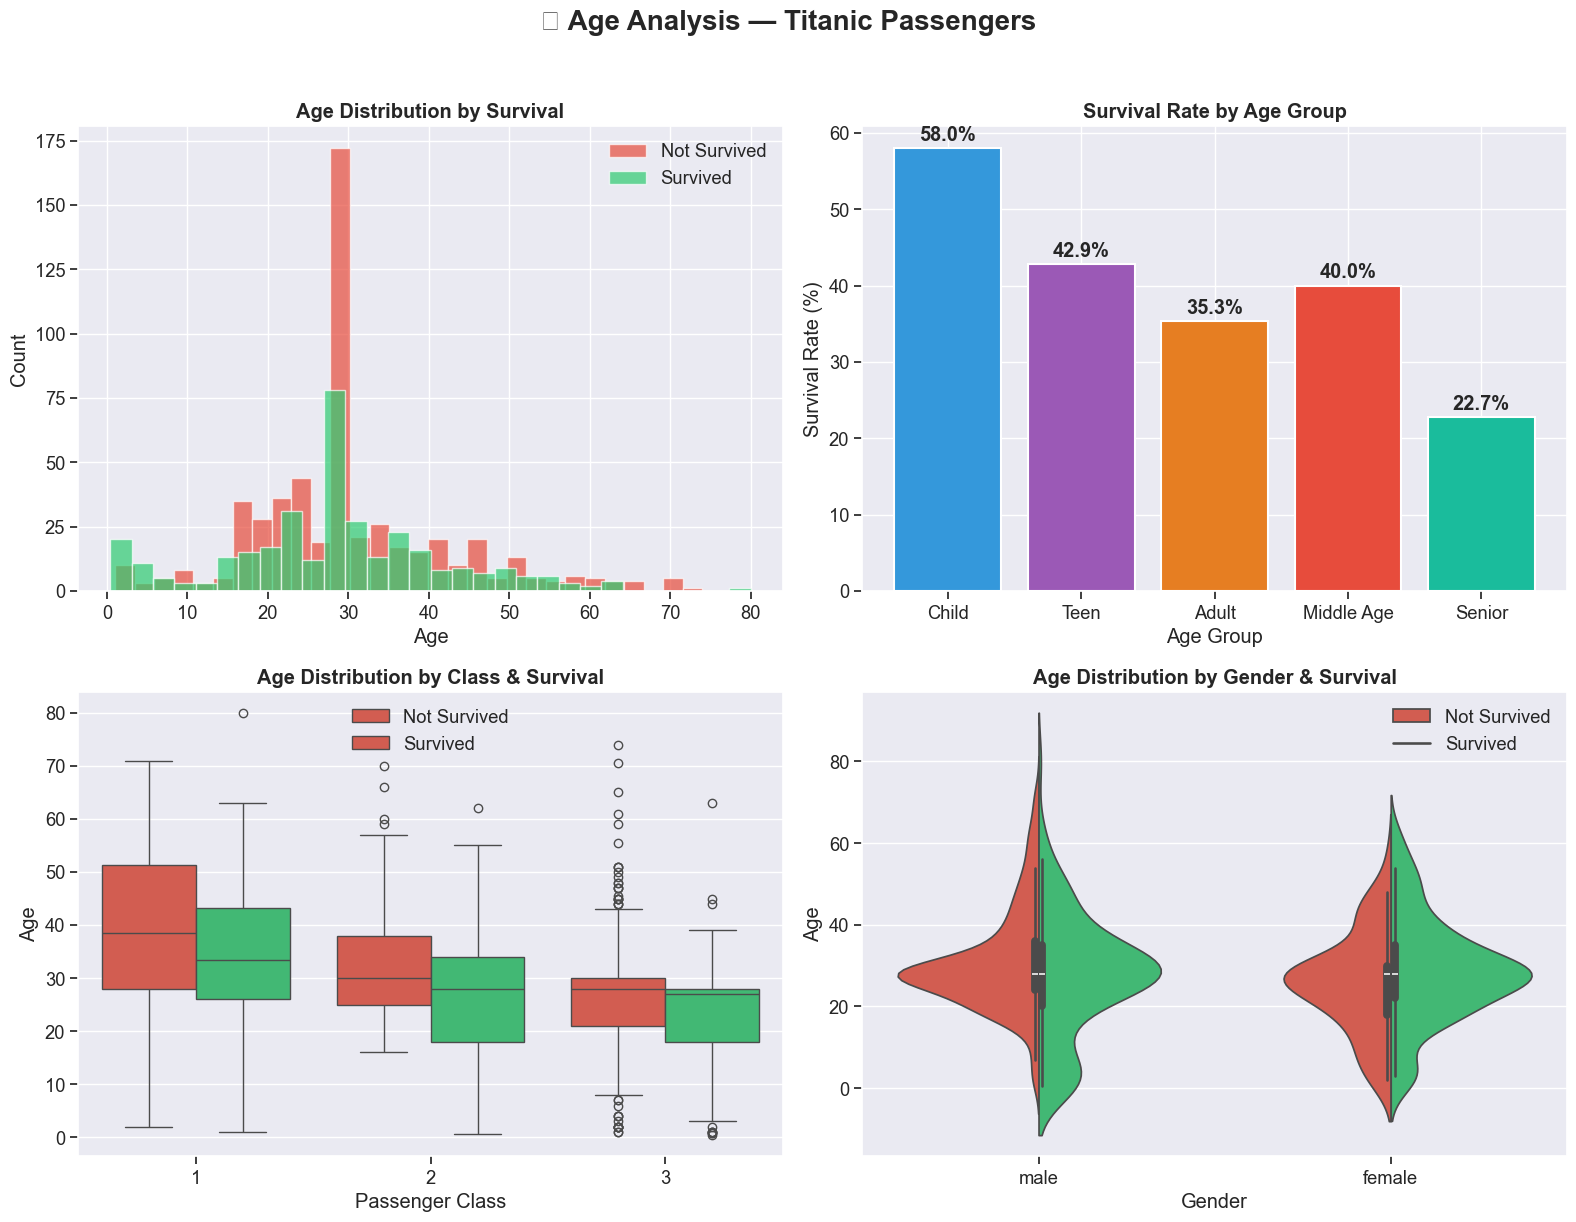

✅ Advanced Age Analysis saved!


In [ ]:

#ADVANCED AGE DISTRIBUTION


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Age Analysis — Titanic Passengers',
             fontsize=20, fontweight='bold', y=1.02)

# Plot 1: Age Distribution by Survival
survived = df[df['Survived']==1]['Age']
not_survived = df[df['Survived']==0]['Age']

axes[0,0].hist(not_survived, bins=30, alpha=0.7, color='#E74C3C', label='Not Survived', edgecolor='white')
axes[0,0].hist(survived, bins=30, alpha=0.7, color='#2ECC71', label='Survived', edgecolor='white')
axes[0,0].set_title('Age Distribution by Survival', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# Plot 2: Age Group Survival Rate
age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100
colors = ['#3498DB','#9B59B6','#E67E22','#E74C3C','#1ABC9C']
axes[0,1].bar(age_survival.index, age_survival.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Survival Rate by Age Group', fontweight='bold')
axes[0,1].set_xlabel('Age Group')
axes[0,1].set_ylabel('Survival Rate (%)')
for i, v in enumerate(age_survival.values):
    axes[0,1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3: Box Plot
sns.boxplot(data=df, x='Pclass', y='Age', hue='Survived',
            palette={0:'#E74C3C', 1:'#2ECC71'}, ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Class & Survival', fontweight='bold')
axes[1,0].set_xlabel('Passenger Class')
axes[1,0].set_ylabel('Age')
axes[1,0].legend(['Not Survived','Survived'])

# Plot 4: Violin Plot
sns.violinplot(data=df, x='Sex', y='Age', hue='Survived',
               palette={0:'#E74C3C', 1:'#2ECC71'},
               split=True, ax=axes[1,1])
axes[1,1].set_title('Age Distribution by Gender & Survival', fontweight='bold')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Age')
axes[1,1].legend(['Not Survived','Survived'])

plt.tight_layout()
plt.savefig('../images/age_analysis_advanced.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Advanced Age Analysis saved!")

# Age Analysis — Explanation
4 Charts inside:

Chart 1 — Age Distribution Histogram:
🟢 Green → Age of passengers who survived
🔴 Red   → Age of passengers who did not survive
    Most deaths occurred in 20-40 age group

Chart 2 — Age Group Survival Rate:
 Children  → Highest survival rate (~58%)
 Seniors   → Lowest survival rate
 Children were rescued first


Chart 3 — Box Plot:
 Box      → Middle 50% of passengers in this range
 Line     → Median (middle) age
 Dots     → Outliers (unusual/extreme ages)

Chart 4 — Violin Plot:
 Wider part  → More passengers at that age
 Narrow part → Fewer passengers at that age
 Female survival was better at every age group

 **Cell 6: Interactive Sunburst Chart**

In [ ]:

#INTERACTIVE SUNBURST CHART

df['Survived_Label'] = df['Survived'].map({0:'Not Survived', 1:'Survived'})
df['Pclass_Label'] = df['Pclass'].map({1:'1st Class', 2:'2nd Class', 3:'3rd Class'})

fig = px.sunburst(df,
                  path=['Survived_Label','Pclass_Label','Sex'],
                  title='🌟 Survival Breakdown — Class & Gender',
                  color='Survived',
                  color_continuous_scale=['#E74C3C','#2ECC71'],
                  height=600)

fig.update_layout(
    title_font_size=20,
    font=dict(size=14)
)

fig.write_html('../dashboard/sunburst_survival.html')
fig.show()
print("✅ Sunburst Chart saved!")

✅ Sunburst Chart saved!


 **Sunburst Chart — Explanation**

How to read it?
 Center    → Survived vs Not Survived
 Middle    → Class breakdown (1st, 2nd, 3rd)
 Outside   → Gender breakdown (Male, Female)
 Bigger slice = More passengers in that group

**Cell 7: Fare Analysis**

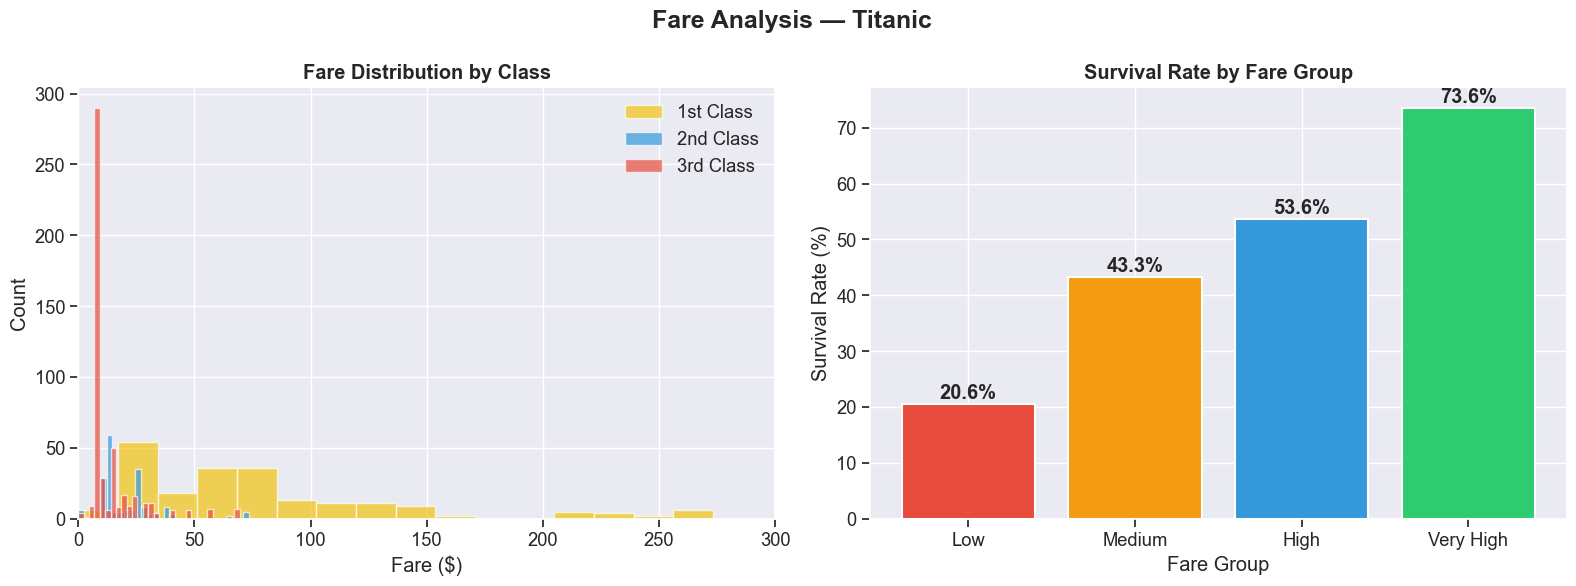

✅ Fare Analysis saved!


In [ ]:

#FARE ANALYSIS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(' Fare Analysis — Titanic', fontsize=18, fontweight='bold')

# Plot 1: Fare Distribution by Class
colors = ['#F1C40F','#3498DB','#E74C3C']
for i, (pclass, color) in enumerate(zip([1,2,3], colors)):
    data = df[df['Pclass']==pclass]['Fare']
    axes[0].hist(data, bins=30, alpha=0.7, color=color,
                label=f'{["1st","2nd","3rd"][i]} Class', edgecolor='white')

axes[0].set_title('Fare Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xlim(0, 300)

# Plot 2: Fare Group Survival
fare_survival = df.groupby('FareGroup')['Survived'].mean() * 100
axes[1].bar(fare_survival.index, fare_survival.values,
            color=['#E74C3C','#F39C12','#3498DB','#2ECC71'],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Survival Rate by Fare Group', fontweight='bold')
axes[1].set_xlabel('Fare Group')
axes[1].set_ylabel('Survival Rate (%)')
for i, v in enumerate(fare_survival.values):
    axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/fare_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Fare Analysis saved!")

**Fare Analysis — Explanation**

Chart 1 — Fare Distribution by Class:
🟡 1st Class → Very high fare ($100-500)
🔵 2nd Class → Medium fare ($10-50)
🔴 3rd Class → Low fare ($5-20)

Chart 2 — Survival Rate by Fare Group:
 Very High fare → ~65% survival rate
 Low fare       → ~20% survival rate
 More money paid = Higher chance of survival

 **Cell 8: Interactive Dashboard**

In [ ]:

#COMPLETE INTERACTIVE DASHBOARD


fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        ' Survival by Gender',
        ' Survival by Class',
        ' Family Size vs Survival',
        ' Fare vs Age (Survival)'
    ),
    specs=[[{"type":"bar"},{"type":"pie"}],
           [{"type":"bar"},{"type":"scatter"}]]
)

# Chart 1: Survival by Gender
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
fig.add_trace(
    go.Bar(x=['Female','Male'],
           y=gender_survival.values,
           marker_color=['#E91E63','#3498DB'],
           text=[f'{v:.1f}%' for v in gender_survival.values],
           textposition='outside',
           name='Gender'),
    row=1, col=1
)

# Chart 2: Survival Pie Chart
survival_counts = df['Survived'].value_counts()
fig.add_trace(
    go.Pie(labels=['Not Survived','Survived'],
           values=survival_counts.values,
           marker_colors=['#E74C3C','#2ECC71'],
           hole=0.4,
           name='Survival'),
    row=1, col=2
)

# Chart 3: Family Size
family_survival = df.groupby('FamilySize')['Survived'].mean() * 100
fig.add_trace(
    go.Bar(x=family_survival.index,
           y=family_survival.values,
           marker_color='#9B59B6',
           name='Family Size'),
    row=2, col=1
)

# Chart 4: Scatter Plot
fig.add_trace(
    go.Scatter(x=df[df['Survived']==0]['Age'],
               y=df[df['Survived']==0]['Fare'],
               mode='markers',
               marker=dict(color='#E74C3C', opacity=0.5, size=6),
               name='Not Survived'),
    row=2, col=2
)
fig.add_trace(
    go.Scatter(x=df[df['Survived']==1]['Age'],
               y=df[df['Survived']==1]['Fare'],
               mode='markers',
               marker=dict(color='#2ECC71', opacity=0.5, size=6),
               name='Survived'),
    row=2, col=2
)

fig.update_layout(
    height=800,
    title_text=' Titanic Complete Analysis Dashboard',
    title_font_size=22,
    showlegend=True,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.write_html('../dashboard/complete_dashboard.html')
fig.show()
print("✅ Complete Interactive Dashboard saved!")

✅ Complete Interactive Dashboard saved!


**Complete Dashboard — Explanation**

4 Charts in one place:
Top Left     → Gender survival bar chart
Top Right    → Overall survival donut chart
Bottom Left  → Family size vs survival rate
Bottom Right → Age vs Fare scatter plot

Scatter Plot Guide:
🟢 Green dots → Passengers who survived
🔴 Red dots   → Passengers who did not survive
 Dots at top → Expensive ticket = Higher survival
 Dots at bottom → Cheap ticket = Lower survival

**Cell 9: Pair Plot**

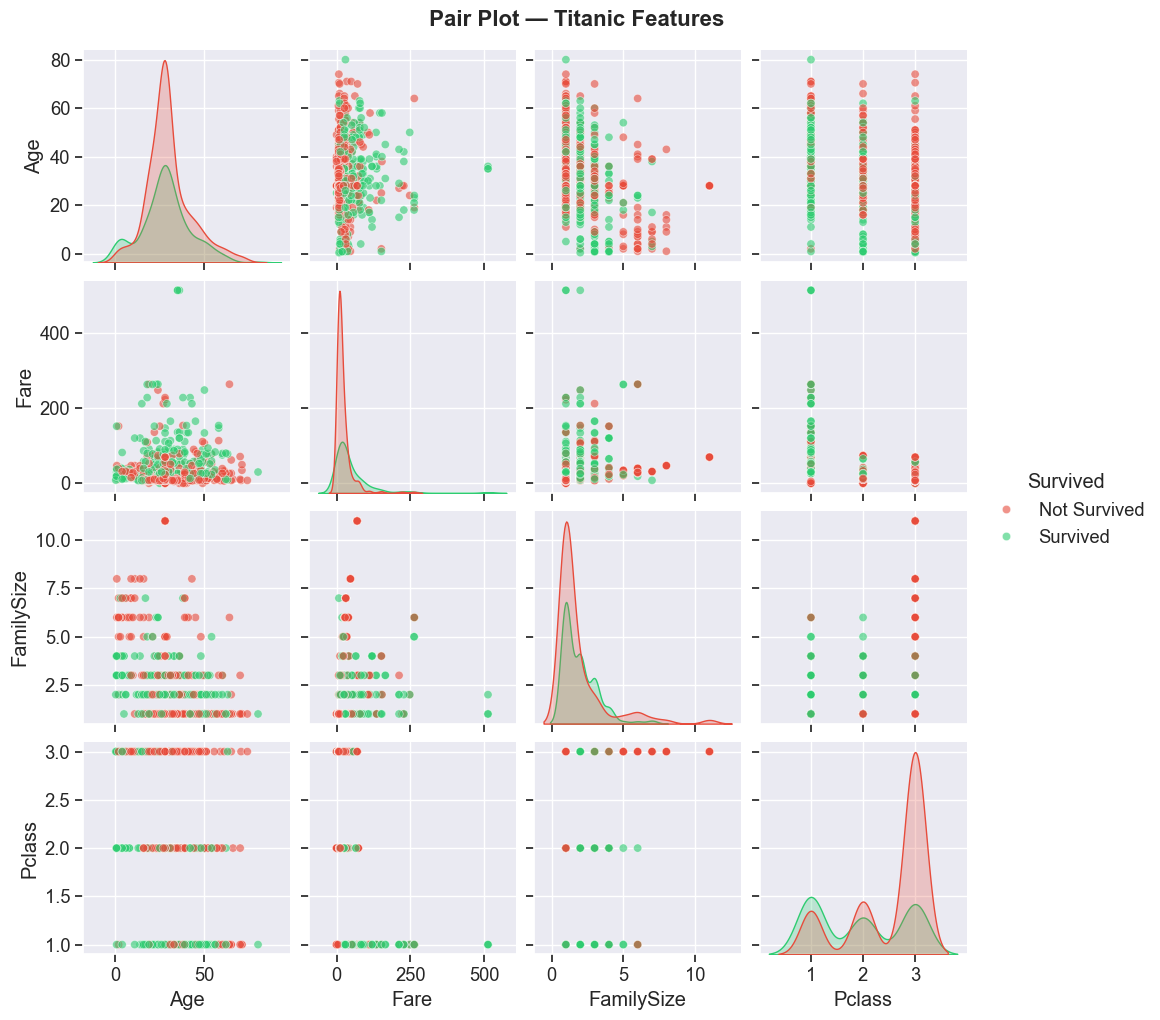

✅ Pair Plot saved!


In [ ]:

#ADVANCED PAIR PLOT

pair_df = df[['Survived','Age','Fare','FamilySize','Pclass']].copy()
pair_df['Survived'] = pair_df['Survived'].map({0:'Not Survived', 1:'Survived'})

g = sns.pairplot(pair_df,
                 hue='Survived',
                 palette={'Not Survived':'#E74C3C','Survived':'#2ECC71'},
                 diag_kind='kde',
                 plot_kws={'alpha':0.6},
                 height=2.5)

g.fig.suptitle(' Pair Plot — Titanic Features',
               fontsize=16, fontweight='bold', y=1.02)

plt.savefig('../images/pair_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Pair Plot saved!")

# Pair Plot — Explanation

 What does this chart show?
 Diagonal boxes   → Distribution of one variable (KDE curve)
 Other boxes      → Scatter plot of two variables
🟢 Green points     → Survived passengers
🔴 Red points       → Not survived passengers

Key Insight:
High Fare + 1st Class = More survival (green dots top left)
Low Fare + 3rd Class  = Less survival (red dots bottom right)

# Cell 10: Final Summary Chart

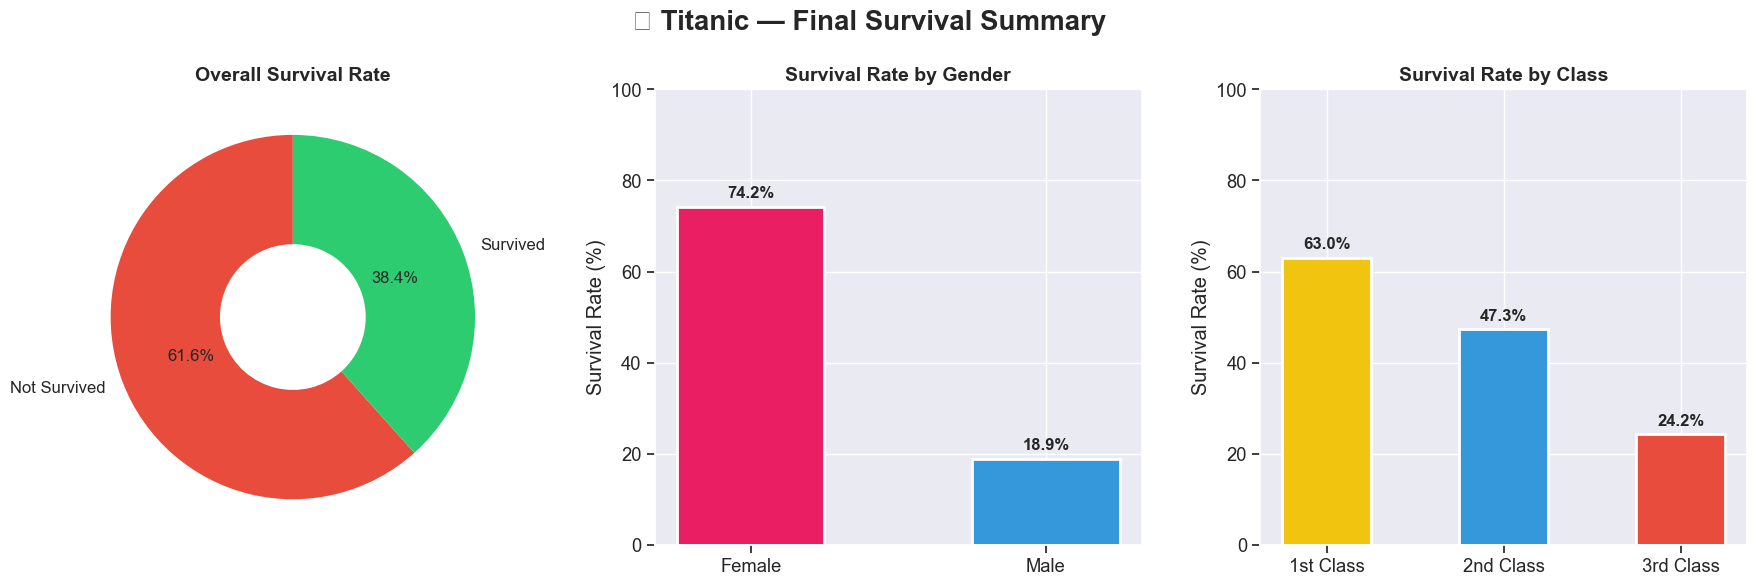

✅ Final Summary Chart saved!

🎉 ALL VISUALIZATIONS COMPLETE!


In [ ]:

#FINAL SUMMARY VISUALIZATION

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🚢 Titanic — Final Survival Summary',
             fontsize=20, fontweight='bold')

# Chart 1: Overall Survival Donut
survival_counts = df['Survived'].value_counts()
colors = ['#E74C3C','#2ECC71']
wedges, texts, autotexts = axes[0].pie(
    survival_counts,
    labels=['Not Survived','Survived'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.6),
    textprops=dict(fontsize=12)
)
axes[0].set_title('Overall Survival Rate', fontweight='bold', fontsize=14)

# Chart 2: Survival by Gender
gender_data = df.groupby('Sex')['Survived'].mean() * 100
bars = axes[1].bar(['Female','Male'], gender_data.values,
                   color=['#E91E63','#3498DB'],
                   edgecolor='white', linewidth=2, width=0.5)
axes[1].set_title('Survival Rate by Gender', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for bar, v in zip(bars, gender_data.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v+2,
                f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Chart 3: Survival by Class
class_data = df.groupby('Pclass')['Survived'].mean() * 100
bars = axes[2].bar(['1st Class','2nd Class','3rd Class'],
                   class_data.values,
                   color=['#F1C40F','#3498DB','#E74C3C'],
                   edgecolor='white', linewidth=2, width=0.5)
axes[2].set_title('Survival Rate by Class', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Survival Rate (%)')
axes[2].set_ylim(0, 100)
for bar, v in zip(bars, class_data.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v+2,
                f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../images/final_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Final Summary Chart saved!")
print("\n🎉 ALL VISUALIZATIONS COMPLETE!")

# Final Summary — Explanation

3 Charts:

Chart 1 — Donut Chart (Overall):
🔴 61.6% → Did NOT survive
🟢 38.4% → Survived

Chart 2 — By Gender:
 Female → 74.2% survived
 Male   → 18.9% survived
 "Women First" policy clearly visible

Chart 3 — By Passenger Class:
 1st Class → 62.9% survived
 2nd Class → 47.3% survived
 3rd Class → 24.2% survived
 Wealthier passengers had better access to lifeboats